<a href="https://colab.research.google.com/github/LegadimaW/Human-Activity-Recognition-ML/blob/main/Member_2/code/Day1_Temporal_Structure_Analysis_HAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

train_df = pd.read_parquet(
    "/content/drive/MyDrive/Human_Activity_Recognition_ML/Data/train_data.parquet"
)

test_df = pd.read_parquet(
    "/content/drive/MyDrive/Human_Activity_Recognition_ML/Data/test_data.parquet"
)

labels_df = pd.read_csv(
    "/content/drive/MyDrive/Human_Activity_Recognition_ML/Data/train_labels.csv"
)

print(train_df.head())


   Sample_ID  Time_Step  Signal_M  Signal_B  Signal_J  Signal_H  Signal_L  \
0          1          0       0.0  0.000007 -0.000057 -0.000185 -0.000099   
1          1          1       0.0  0.000007 -0.000057 -0.000185 -0.000099   
2          1          2       0.0  0.000007 -0.000057 -0.000185 -0.000099   
3          1          3       0.0  0.000007 -0.000057 -0.000185 -0.000099   
4          1          4       0.0  0.000007 -0.000057 -0.000185 -0.000099   

   Signal_F  Signal_D  Signal_A  Signal_G  Signal_K  Signal_C  Signal_E  \
0 -0.000137  0.000016 -0.000019  0.000025  0.000122  0.000104 -0.000016   
1 -0.000137  0.000016 -0.000019  0.000025  0.000122  0.000104 -0.000016   
2 -0.000137  0.000016 -0.000019  0.000025  0.000122  0.000104 -0.000016   
3 -0.000137  0.000016 -0.000019  0.000025  0.000122  0.000104 -0.000016   
4 -0.000137  0.000016 -0.000019  0.000025  0.000122  0.000104 -0.000016   

   Signal_I  Signal_N  
0  0.000051 -0.000161  
1  0.000051 -0.000190  
2  0.000051 -0

In [ ]:
#IT HAS 14 COLS/SIGNALS
signal_cols = [
    col for col in train_df.columns
    if col not in ["Sample_ID", "Time_Step"]
]

print(signal_cols)

print("Number of signals:", len(signal_cols))

['Signal_M', 'Signal_B', 'Signal_J', 'Signal_H', 'Signal_L', 'Signal_F', 'Signal_D', 'Signal_A', 'Signal_G', 'Signal_K', 'Signal_C', 'Signal_E', 'Signal_I', 'Signal_N']
Number of signals: 14


In [ ]:
#CHECKING 100 ROWS
rows_per_sample = train_df.groupby("Sample_ID").size()

print(rows_per_sample.describe())
print(rows_per_sample.value_counts())

count    2793.0
mean      100.0
std         0.0
min       100.0
25%       100.0
50%       100.0
75%       100.0
max       100.0
dtype: float64
100    2793
Name: count, dtype: int64


In [ ]:
#Checking for broken samples

bad_samples = rows_per_sample[rows_per_sample != 100]

print("Bad samples:", len(bad_samples))
print(bad_samples.head())

Bad samples: 0
Series([], dtype: int64)


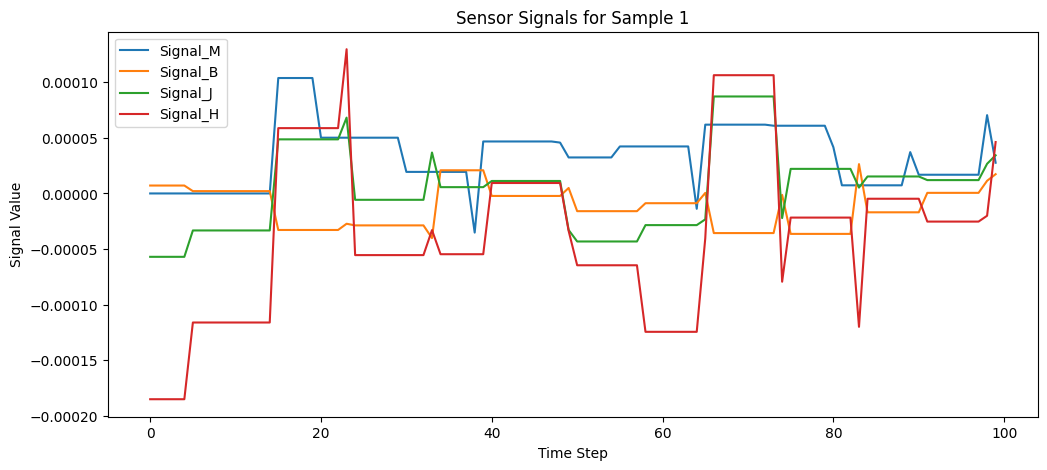

In [ ]:
#Plot sample sequences
import matplotlib.pyplot as plt

sample_id = 1

sample = train_df[
    train_df["Sample_ID"] == sample_id
].sort_values("Time_Step")

plt.figure(figsize=(12,5))

for col in signal_cols[:4]:
    plt.plot(
        sample["Time_Step"],
        sample[col],
        label=col
    )

plt.title(f"Sensor Signals for Sample {sample_id}")

plt.xlabel("Time Step")

plt.ylabel("Signal Value")

plt.legend()

plt.show()

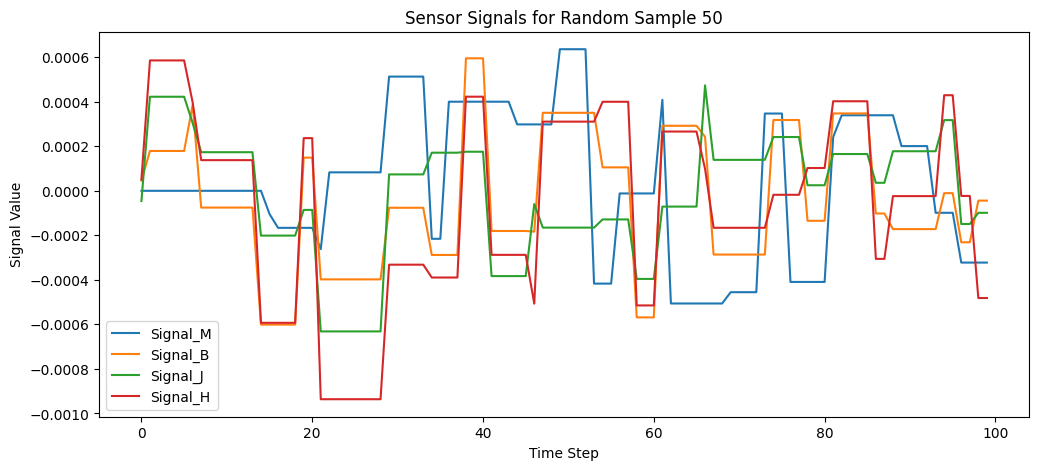

In [ ]:
sample_id = 50

sample = train_df[
    train_df["Sample_ID"] == sample_id
].sort_values("Time_Step")

plt.figure(figsize=(12,5))

for col in signal_cols[:4]:
    plt.plot(
        sample["Time_Step"],
        sample[col],
        label=col
    )

plt.title(f"Sensor Signals for Random Sample {sample_id}")

plt.xlabel("Time Step")

plt.ylabel("Signal Value")

plt.legend()

plt.show()